In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from google.colab import files

PARTIE 1 : Schémas d’Euler

In [23]:
#Schéma d'Euler explicite
def fct_euler_exp(lambd, u0, h, T): #lambd=coefficient de Malthus, u0=la condition initiale, h=le pas de de temps, T=t_max
    #Initialisation :
    un = u0 #n=0
    tn = 0 #n=0
    liste_un = [u0] #liste des valeurs de u_n pour n allant de O à N #Avec u_n les valeurs approchées de la solution
    liste_tn = [tn] #liste des valeurs de t_n pour n allant de O à N+1 #Avec t_n le temps, t_n=les noeuds du maillage
    while tn<T :
        un = un + h*lambd*un #u_n+1=u_n+h*f(u_n)=u_n+h*(λ*u_n) car u'(t)=λ*u(t) ==> f(u)=λ*u #Euler explicite + Malthus
        liste_un.append(un) #on met la valeur de u_n dans la liste
        tn= tn + h #t_n+1<--t_n+h
        liste_tn.append(tn) # on met la valeur de t_n dans la liste
    return liste_tn, liste_un

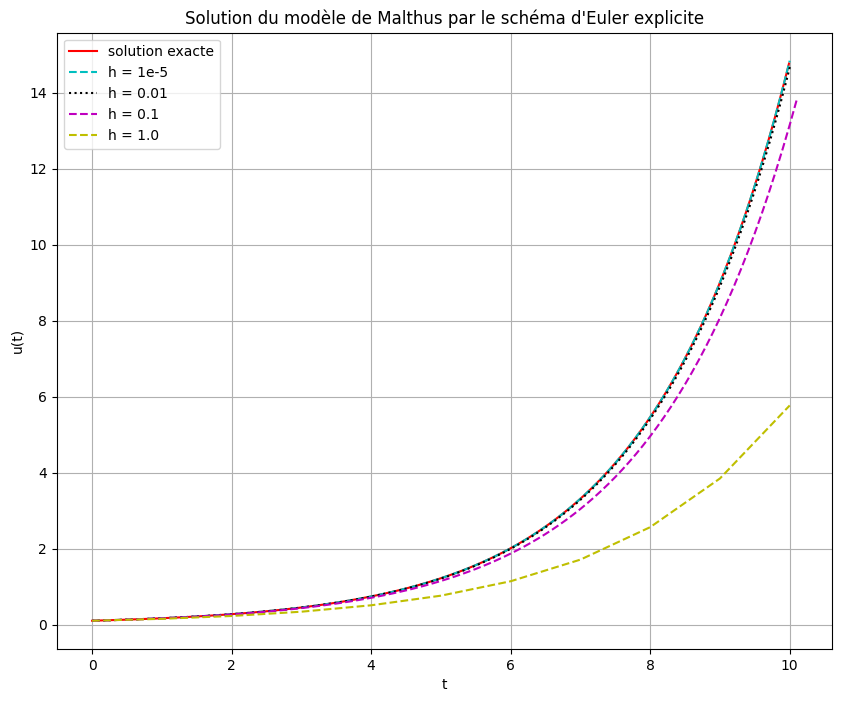

In [24]:
#Pour chaque cas, on a les valeurs :
lambd = 0.5; u0 = 0.1; T = 10

#Les solutions exactes de Malthus s'écrivent :
t = np.arange(0, T, 0.01) #t=temps de 0 à T avec un pas de 0.01
solution_exacte = u0*np.exp(lambd*t)

#Cas1:
h = 1e-5
t1, solution1 = fct_euler_exp(lambd, u0, h, T)
#Cas2:
h = 0.01
t2, solution2 = fct_euler_exp(lambd, u0, h, T)
#Cas3:
h = 0.1
t3, solution3 = fct_euler_exp(lambd, u0, h, T)
#Cas4:
h = 1
t4, solution4 = fct_euler_exp(lambd, u0, h, T)

#Graphique :
plt.figure(figsize=(10,8))  # Fixe la taille du graphique
plt.plot(t, solution_exacte, "-r", label = "solution exacte")
plt.plot(t1, solution1, "--c", label = "h = 1e-5")
plt.plot(t2, solution2, ":k", label = "h = 0.01")
plt.plot(t3, solution3, "--m", label = "h = 0.1")
plt.plot(t4, solution4, "--y", label = "h = 1.0")
plt.title("Solution du modèle de Malthus par le schéma d'Euler explicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid() #Affiche la grille
plt.show()

On constate que les solutions avec h=0.01 et h=1e-5 approximent mieux la solution exacte que celles avec avec h=0.1 et h=1. On constate donc que plus h est petit, meilleur sera l'approximation. On remarque aussi que pour h grand, la courbe obtenue sera en-dessous de la courbe de la solution exacte sur le graphique.

In [25]:
#Schéma d'Euler implicite
def fct_euler_imp(lambd, u0, h, T):
    #Initialisation :
    un = u0 #n=0
    tn = 0 #n=0
    liste_un = [u0]
    liste_tn = [tn]
    while tn < T :
        un = un/(1-lambd*h) #u_n+1=u_n/(1-h*λ) d'après la question 1.11)
        liste_un.append(un)
        tn= tn+h
        liste_tn.append(tn)
    return liste_tn, liste_un

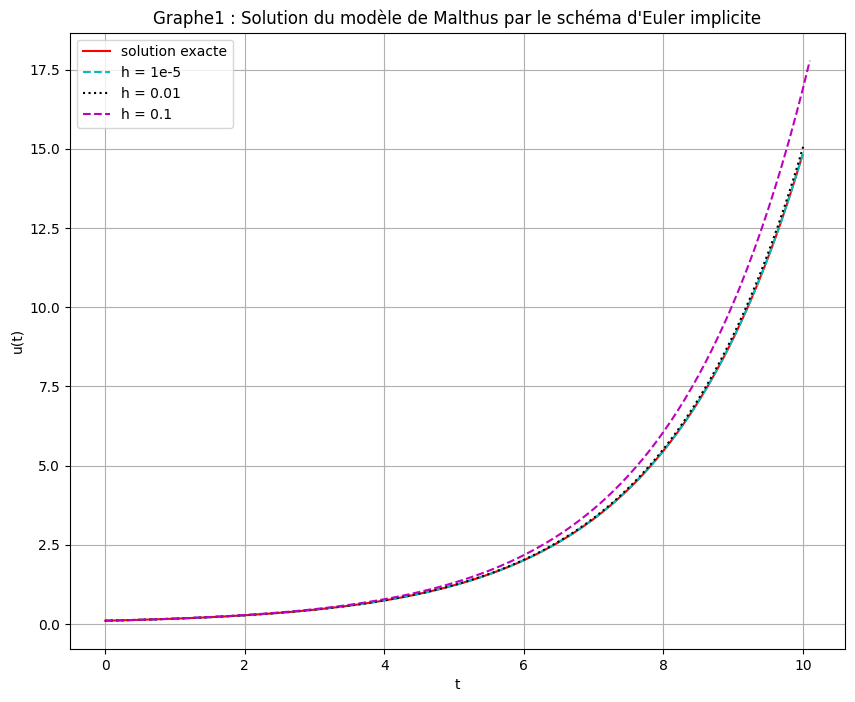

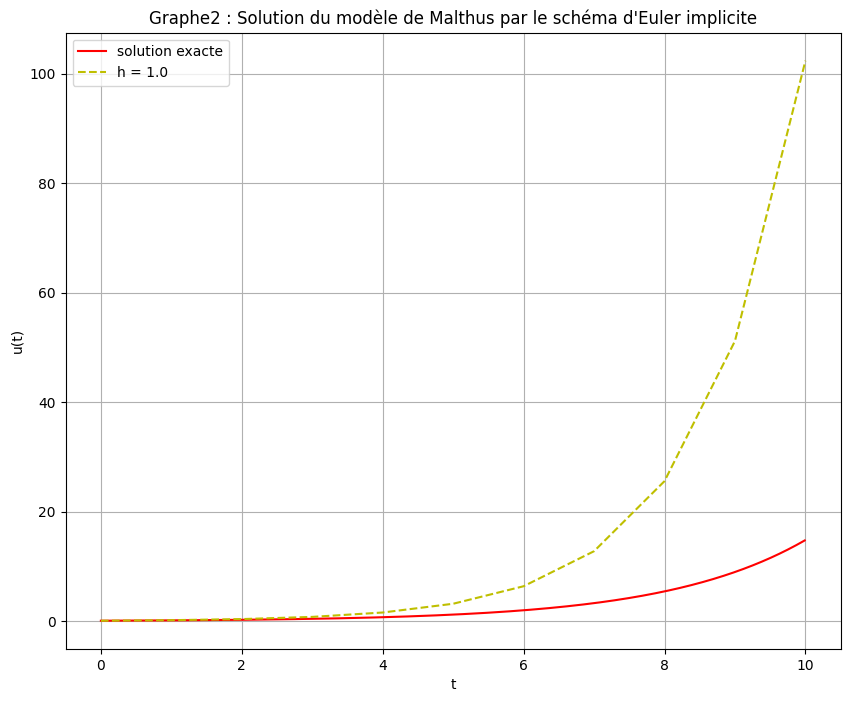

In [26]:
#Pour chaque exemple on a les valeurs :
lambd = 0.5; u0 = 0.1; T = 10

#Les solutions exactes de Malthus s'écrivent :
t = np.arange(0, T, 0.01) #t=temps de 0 à T avec un pas de 0.01
solution_exacte = u0*np.exp(lambd*t)

#Cas1:
h = 1e-5
t1, solution1 = fct_euler_imp(lambd, u0, h, T)
#Cas2:
h = 0.01
t2, solution2 = fct_euler_imp(lambd, u0, h, T)
#Cas3:
h = 0.1
t3, solution3 = fct_euler_imp(lambd, u0, h, T)
#Cas4:
h = 1.0
t4, solution4 = fct_euler_imp(lambd, u0, h, T)

#Graphe1
plt.figure(figsize=(10,8))
plt.plot(t, solution_exacte, "-r", label = "solution exacte")
plt.plot(t1, solution1, "--c", label = "h = 1e-5")
plt.plot(t2, solution2, ":k", label = "h = 0.01")
plt.plot(t3, solution3, "--m", label = "h = 0.1")
plt.title("Graphe1 : Solution du modèle de Malthus par le schéma d'Euler implicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()

#Graphe2
plt.figure(figsize=(10,8))
plt.plot(t, solution_exacte, "-r", label = "solution exacte")
plt.plot(t4, solution4, "--y", label = "h = 1.0")
plt.title("Graphe2 : Solution du modèle de Malthus par le schéma d'Euler implicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()

Dans le Graphe2 les cas h=1e-5 et h=0.01 sont de bonnes approximations de la solution exacte mais le cas h=0.1 n'est pas très bon.
Dans le Graphe3 on constate clairement que le cas h=1 est une mauvaise approximation.
On en conclut comme pour le cas explicite, que le cas implicite donne de meilleures approximations pour un h petit. On remarque aussi que pour h grand, la courbe obtenue sera au-dessus de la courbe de la solution exacte sur le graphique.

PARTIE 2 : Schémas point milieu et de Crank-Nicholson

In [27]:
#Schémas point milieu
def fct_point_milieu_log(r, K, u0, h, T): #r=un coefficient, K=la capacité de charge , u0=la condition initiale, h=le pas de temps, T=t_max
    #Initialisation :
    un = u0 #n=0
    tn = 0 #n=0
    liste_un = [u0]
    liste_tn = [tn]
    while tn<T :
        y = un+0.5*h*r*un*(1 - un/K) #dans u_n+1=u_n+h*f(u_n+0.5*h*f(u_n)) on s'occupe d'abord de ce qu'il y a dans la grosse parenthèse que l'on va noter y grâce au modèle logistique.
        un = un + h *r*y*(1 - y/K) #ce qui nous donne u_n+1=u_n+h*f(y)
        liste_un.append(un)
        tn = tn + h
        liste_tn.append(tn)
    return liste_tn, liste_un

In [28]:
#On écrit la fonction racine qui calcule les racines d'un polynôme de degré 2 dans le cas où le discriminant est positif.
#Et la fonction, renvoie une seule racine qui est la plus grande et qui est positive.
#On va utiliser la fonction racine pour les fonctions fct_crank_nicholson_log et fct_euler_imp_log.
#Pour le détail du polynôme de degré 2 voir feuille compte rendu.
def racines(a, b, c):
    delta = b**2 - 4*a*c
    racine = (-b + np.sqrt(delta)) / (2*a) #calcul de la racine positive
    return racine

def fct_crank_nicholson_log(r, K, u0, h, T):
    #Initialisation :
    un = u0 #n=0
    tn = 0 #n=0
    liste_un = [u0]
    liste_tn = [tn]
    while tn<T :
        un=racines(0.5*h*r/K, 1-0.5*h*r, 0.5*h*r*(un**2/K -un)-un) #on calcule la racine positive du polynôme aX+bX+c avec X=u_n+1 et un=u_n
        liste_un.append(un)
        tn= tn+h
        liste_tn.append(tn)
    return liste_tn, liste_un


In [29]:
def fct_euler_imp_log(r, K, u0, h, T):
    #Initialisation :
    un = u0 #n=0
    tn = 0 #n=0
    liste_un = [u0]
    liste_tn = [tn]
    while tn < T :
        un=racines(h*r/K, 1-h*r, -un) #on calcule la racine positive du polynôme aX+bX+c avec X=u_n+1 et un=u_n
        liste_un.append(un)
        tn= tn+h
        liste_tn.append(tn)
    return liste_tn, liste_un

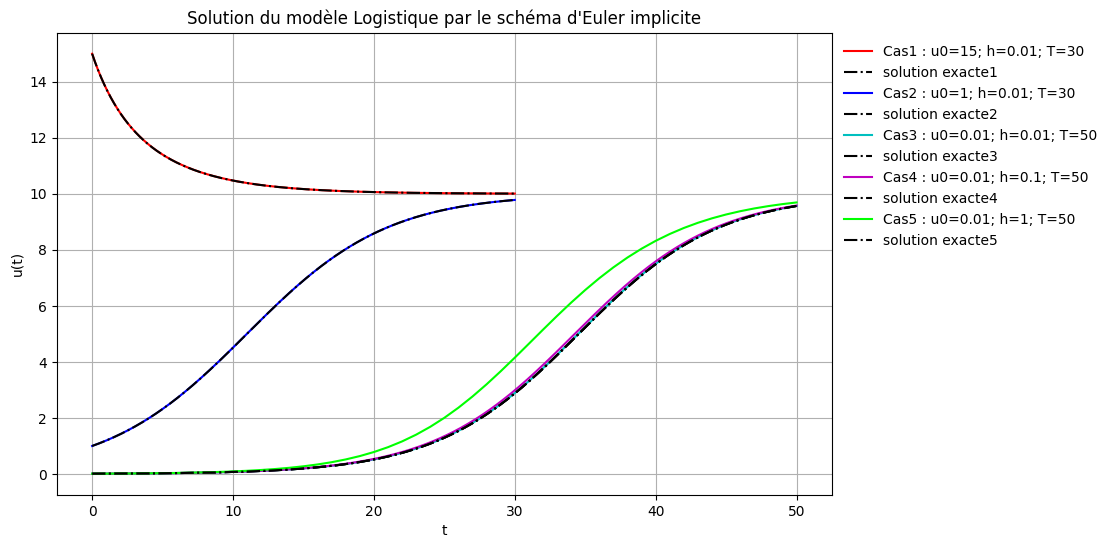

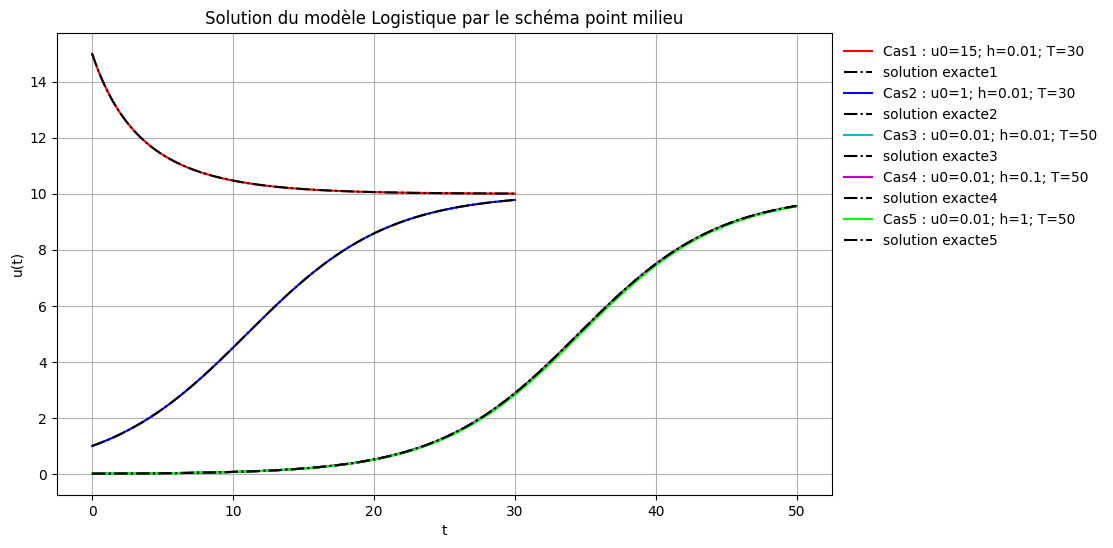

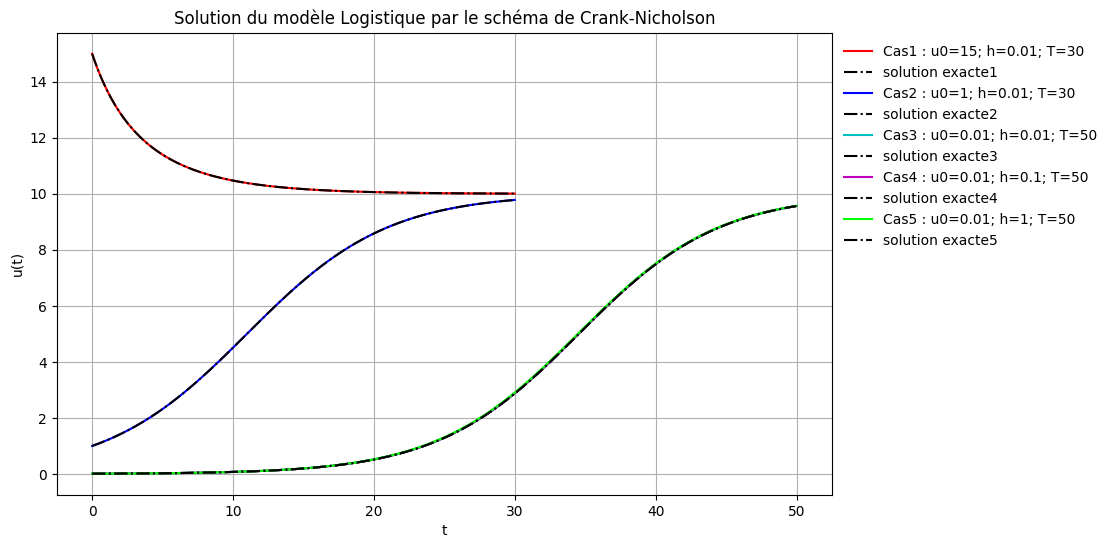

In [30]:
#Pour chaque exemple on a les valeurs :
r=0.2; K=10

#Cas1:
u0=15; h=0.01; T=30
t1_eul_imp_log, u1_eul_imp_log = fct_euler_imp_log(r, K, u0, h, T)
t1_pt_mil_log, u1_pt_mil_log = fct_point_milieu_log(r, K, u0, h, T)
t1_crank_nich, u1_crank_nich = fct_crank_nicholson_log(r, K, u0, h, T)
#Les solutions exactes Logistique s'écrivent :
t1 = np.arange(0, 30, 0.01) #t=temps de 0 à T avec un pas de 0.01
solution_exacte1 = u0*K/(u0+(K-u0)*np.exp(-r*t1))
#Cas2:
u0=1; h=0.01; T=30
t2_eul_imp_log, u2_eul_imp_log = fct_euler_imp_log(r, K, u0, h, T)
t2_pt_mil_log, u2_pt_mil_log = fct_point_milieu_log(r, K, u0, h, T)
t2_crank_nich, u2_crank_nich = fct_crank_nicholson_log(r, K, u0, h, T)
#Les solutions exactes Logistique s'écrivent :
t2 = np.arange(0, 30, 0.01) #t=temps de 0 à T avec un pas de 0.01
solution_exacte2 = u0*K/(u0+(K-u0)*np.exp(-r*t2))
#Cas3:
u0=0.01; h=0.01; T=50
t3_eul_imp_log, u3_eul_imp_log = fct_euler_imp_log(r, K, u0, h, T)
t3_pt_mil_log, u3_pt_mil_log = fct_point_milieu_log(r, K, u0, h, T)
t3_crank_nich, u3_crank_nich = fct_crank_nicholson_log(r, K, u0, h, T)
#Les solutions exactes Logistique s'écrivent :
t3 = np.arange(0, 50, 0.01) #t=temps de 0 à T avec un pas de 0.01
solution_exacte3 = u0*K/(u0+(K-u0)*np.exp(-r*t3))
#Cas4:
u0=0.01; h=0.1; T=50
t4_eul_imp_log, u4_eul_imp_log = fct_euler_imp_log(r, K, u0, h, T)
t4_pt_mil_log, u4_pt_mil_log = fct_point_milieu_log(r, K, u0, h, T)
t4_crank_nich, u4_crank_nich = fct_crank_nicholson_log(r, K, u0, h, T)
#Les solutions exactes Logistique s'écrivent :
t4 = np.arange(0, 50, 0.01) #t=temps de 0 à T avec un pas de 0.01
solution_exacte4 = u0*K/(u0+(K-u0)*np.exp(-r*t4))
#Cas5:
u0=0.01; h=1; T=50
t5_eul_imp_log, u5_eul_imp_log = fct_euler_imp_log(r, K, u0, h, T)
t5_pt_mil_log, u5_pt_mil_log = fct_point_milieu_log(r, K, u0, h, T)
t5_crank_nich, u5_crank_nich = fct_crank_nicholson_log(r, K, u0, h, T)
#Les solutions exactes Logistique s'écrivent :
t5 = np.arange(0, 50, 0.01) #t=temps de 0 à T avec un pas de 0.01
solution_exacte5 = u0*K/(u0+(K-u0)*np.exp(-r*t5))


#Graphe Euler implicite
plt.figure(figsize=(10, 6))
plt.plot(t1_eul_imp_log, u1_eul_imp_log, "-r", label = "Cas1 : u0=15; h=0.01; T=30")
plt.plot(t1, solution_exacte1, "-.k", label = "solution exacte1")
plt.plot(t2_eul_imp_log, u2_eul_imp_log, "-b", label = "Cas2 : u0=1; h=0.01; T=30")
plt.plot(t2, solution_exacte2, "-.k", label = "solution exacte2")
plt.plot(t3_eul_imp_log, u3_eul_imp_log, "-c", label = "Cas3 : u0=0.01; h=0.01; T=50")
plt.plot(t3, solution_exacte3, "-.k", label = "solution exacte3")
plt.plot(t4_eul_imp_log, u4_eul_imp_log, "m", label = "Cas4 : u0=0.01; h=0.1; T=50")
plt.plot(t4, solution_exacte4, '-.k', label = "solution exacte4")
plt.plot(t5_eul_imp_log, u5_eul_imp_log, "lime", label = "Cas5 : u0=0.01; h=1; T=50")
plt.plot(t5, solution_exacte5, "-.k", label = "solution exacte5")
plt.title("Solution du modèle Logistique par le schéma d'Euler implicite")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False) # Met la légende à droite du graphique
plt.grid()
plt.show()

#Graphe point milieu
plt.figure(figsize=(10, 6))
plt.plot(t1_pt_mil_log, u1_pt_mil_log, "-r", label = "Cas1 : u0=15; h=0.01; T=30")
plt.plot(t1, solution_exacte1, "-.k", label = "solution exacte1")
plt.plot(t2_pt_mil_log, u2_pt_mil_log, "-b", label = "Cas2 : u0=1; h=0.01; T=30")
plt.plot(t2, solution_exacte2, "-.k", label = "solution exacte2")
plt.plot(t3_pt_mil_log, u3_pt_mil_log, "-c", label = "Cas3 : u0=0.01; h=0.01; T=50")
plt.plot(t3, solution_exacte3, "-.k", label = "solution exacte3")
plt.plot(t4_pt_mil_log, u4_pt_mil_log, "-m", label = "Cas4 : u0=0.01; h=0.1; T=50")
plt.plot(t4, solution_exacte4, "-.k", label = "solution exacte4")
plt.plot(t5_pt_mil_log, u5_pt_mil_log, "lime", label = "Cas5 : u0=0.01; h=1; T=50")
plt.plot(t5, solution_exacte5, "-.k", label = "solution exacte5")
plt.title("Solution du modèle Logistique par le schéma point milieu")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.grid()
plt.show()

#Graphe Crank-Nicholson
plt.figure(figsize=(10, 6))
plt.plot(t1_crank_nich, u1_crank_nich, "-r", label = "Cas1 : u0=15; h=0.01; T=30")
plt.plot(t1, solution_exacte1, "-.k", label = "solution exacte1")
plt.plot(t2_crank_nich, u2_crank_nich, "-b", label = "Cas2 : u0=1; h=0.01; T=30")
plt.plot(t2, solution_exacte2, "-.k", label = "solution exacte2")
plt.plot(t3_crank_nich, u3_crank_nich, "-c", label = "Cas3 : u0=0.01; h=0.01; T=50")
plt.plot(t3, solution_exacte3, "-.k", label = "solution exacte3")
plt.plot(t4_crank_nich, u4_crank_nich, "-m", label = "Cas4 : u0=0.01; h=0.1; T=50")
plt.plot(t4, solution_exacte4, "-.k", label = "solution exacte4")
plt.plot(t5_crank_nich, u5_crank_nich, "lime", label = "Cas5 : u0=0.01; h=1; T=50")
plt.plot(t5, solution_exacte5, "-.k", label = "solution exacte5")
plt.title("Solution du modèle Logistique par le schéma de Crank-Nicholson")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.grid()
plt.show()

On constate que pour le cas 4 (h=0.1) le shéma d'Euler implicite n'approche pas correctement la courbe de la solution, ce qui est encore plus flagrent pour le cas 5 (h=1) où le shéma d'Euler implicite est très éloigné de la solution exacte. On peut facilement conjecturer que plus h est grand, plus le shéma d'Euler implicite approche mal la solution exacte. En revanche les schémas point milieu et Crank-Nichlson approximent très bien les solutions exactes pour les différents h sauf pour le cas 5 où on peut voir que les courbes ne se superposent plus totalement, la courbe de la fonction de Crank-Nicholson étant légèrement au-dessus de la courbe de la solution exacte et celle de la fonction point milieu étant légèrement en-dessous de la courbe de la solution exacte.

En conclusion :

Le schéma d'Euler implicite est un schéma convergeant d'odre 1 et les schémas point milieu et Crank-Nicholson sont des schémas convergents d'odre 2. Donc point milieu et Crank-Nicholson auront une meilleure approximation que Euler implicite.

En termes de temps de calcul c'est la fonction euler_imp_log qui est la moins coûteuse (car moins d'opérations scalaires).

On a deux schémas implicites : Euler implicite et Crank-Nicholson. Et un schéma explicite : point milieu.

Donc parmis ces trois schémas, le schéma point milieu semble être le meileur compromis car il est convergent d'ordre 2 et explicite, de plus, son temps de calcul se situe entre les deux autres schémas, avec le schéma d'Euler implicite qui est le plus rapide et le schéma de Crank-Nicholson qui est le plus lent.

PARTIE 3 : Croissance tumorale et estimation de paramètres

Saving Data tumeur to Data tumeur (1)
    0      1
0   7   81.2
1  10  178.6
2  11   99.6
3  12  115.3
4  13  162.8


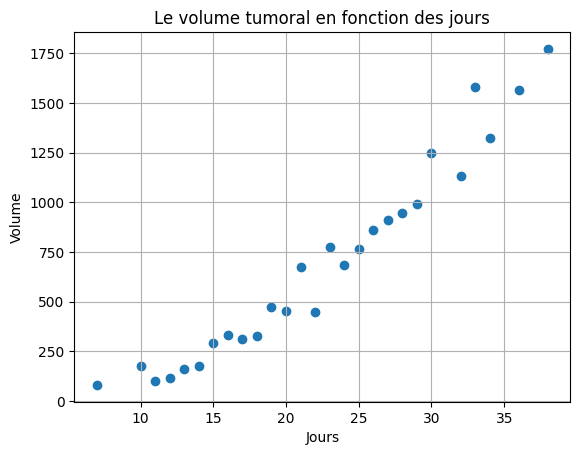

In [31]:
uploaded = files.upload() #Sélectionner le fichier DataTumeur
chemin = list(uploaded.keys())[0]
df = pd.read_csv(chemin, sep='\t', header=None)
t = df[0].values
y = df[1].values
print(df.head())
plt.scatter(df[0], df[1], marker='o')
plt.title("Le volume tumoral en fonction des jours")
plt.xlabel("Jours")
plt.ylabel("Volume")
plt.grid()
plt.show()


In [32]:
#Modèle de Malthus :
def modele_malthus(t, u0, lambd):
    return u0 * np.exp(lambd * t) #formule de la solution exacte

def erreur_malthus(params, t, y):
    u0 = y[0]  #Initialisation
    lambd = params[0]
    u_predM = modele_malthus(t, u0, lambd) #calcul des valeurs prédites avec le modèle
    return np.sum((u_predM - y)**2) #erreur des moindres carrés

params_initM = [0.1] #estimation initiale de λ
resultM = minimize(erreur_malthus, params_initM, args=(t, y), bounds=((0, None),)) #minimisation de l'erreur des moindres carrés pour estimer λ
lambda_estimeM = resultM.x[0] # paramètre λ estimé

print("Modèle de Malthus:")
print(f"Valeur estimée de lambda : {lambda_estimeM}")
print(f"Erreur totale (somme des carrés des erreurs) : {resultM.fun}") #donne la somme des carrés des erreurs à la solution optimale
y_predM = modele_malthus(t, y[0], lambda_estimeM) #calcul des valeurs prédites avec le modèle de Malthus



# Modèle Logistique :
def modele_logistique(t, u0, r, K):
    return (K * u0) / (u0 + (K - u0) * np.exp(-r * t))

def erreur_logistique(params, t, y):
    u0 = y[0] #Initialisation
    r, K = params #Paramètres r et K
    u_predL = modele_logistique(t, u0, r, K)
    return np.sum((u_predL - y)**2)

params_initL = [0.1, 1000] #estimation initiale de r et K
resultL = minimize(erreur_logistique, params_initL, args=(t, y), bounds=((0, None), (0, None)))
r_estimeL, K_estimeL = resultL.x #paramètres r et K estimés

print("\nModèle Logistique :")
print(f"Valeur estimée de r : {r_estimeL}")
print(f"Valeur estimée de K : {K_estimeL}")
print(f"Erreur totale (somme des carrés des erreurs) : {resultL.fun}")
y_predL = modele_logistique(t, y[0], r_estimeL, K_estimeL)



# Modèle de Gompertz :
def modele_gompertz(t, u0, r, K): #Pour le détail du calcul de la solution exacte du modèle deGompertz voir feuille compte rendu.
    v0 = np.log(K / u0) #Calcul de v0
    return K * np.exp(-v0 * np.exp(-r * t))

def erreur_gompertz(params, t, y):
    u0 = y[0] #condition initiale estimée
    r, K = params #paramètres r et K
    u_predG = modele_gompertz(t, u0, r, K)
    return np.sum((u_predG - y)**2)

params_initG = [0.1, 1000] #estimation initiale de r et K
resultG = minimize(erreur_gompertz, params_initG, args=(t, y), bounds=((0, None), (0, None)))
r_estimeG, K_estimeG = resultG.x #paramètres r et K estimés

print("\nModèle de Gompertz:")
print(f"Valeur estimée de r : {r_estimeG}")
print(f"Valeur estimée de K : {K_estimeG}")
print(f"Erreur totale (somme des carrés des erreurs) : {resultG.fun}")
y_predG = modele_gompertz(t, y[0], r_estimeG, K_estimeG)

Modèle de Malthus:
Valeur estimée de lambda : 0.0843227143961477
Erreur totale (somme des carrés des erreurs) : 403125.2158146141

Modèle Logistique :
Valeur estimée de r : 0.09697540413850184
Valeur estimée de K : 3930.090654622795
Erreur totale (somme des carrés des erreurs) : 254368.5133789429

Modèle de Gompertz:
Valeur estimée de r : 0.01771178371059796
Valeur estimée de K : 44121.46038115132
Erreur totale (somme des carrés des erreurs) : 301061.19303275883


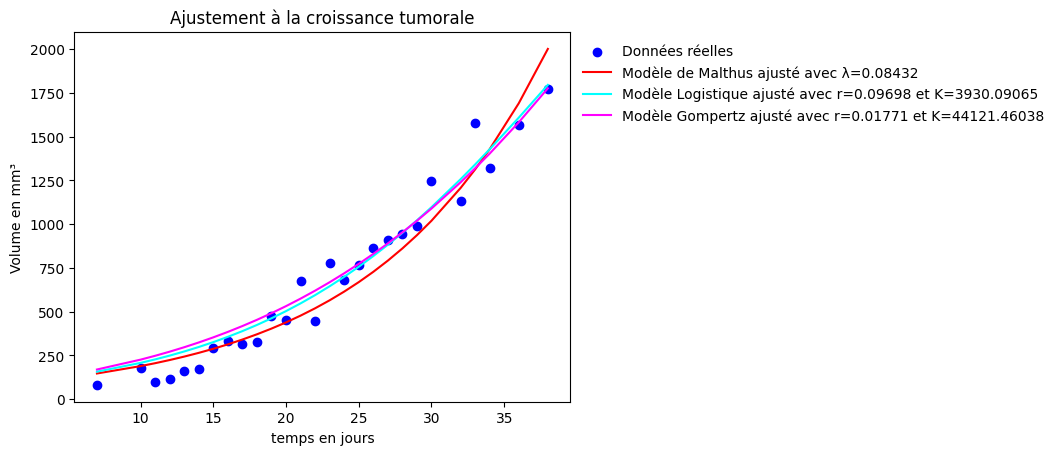

In [33]:
#Tout sur un seul graphique
plt.scatter(t, y, color="blue", label="Données réelles")
plt.plot(t, y_predM, label=f'Modèle de Malthus ajusté avec λ={lambda_estimeM:.5f}', linestyle="-", color="red")
plt.plot(t, y_predL, label=f'Modèle Logistique ajusté avec r={r_estimeL:.5f} et K={K_estimeL:.5f}', linestyle="-", color="cyan")
plt.plot(t, y_predG, label=f'Modèle Gompertz ajusté avec r={r_estimeG:.5f} et K={K_estimeG:.5f}', linestyle="-", color="magenta")
plt.xlabel("temps en jours")
plt.ylabel("Volume en mm³")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
plt.title("Ajustement à la croissance tumorale")
plt.show()

Graphiquement, on peut émettre l'hypothèe que le modèle de Malthus est celui qui décrit le moins bien la croissance tumorale car la courbe passe par moins de valeurs réelles que les deux autres modèles (potentielle risque de sous apprentissage ?). Mais un meilleur argument est que le modèle de Malthus est celui qui a l'erreur totale (des moindres carrés) la plus élevée avec une valeur de 403125.

Pour le modèle de Gombertz et le modèle logistique leurs courbes approximent le nuage point de manière assez équivalente.

Donc pour les départager, on va comparer leurs erreurs totales, et il se trouve que c'est le modèle logistique qui a l'erreur totale la plus faible avec 254368 contre 301657 pour le modèle de Gompertz.

Il semblerait donc que le modèle logistique soit le plus adapté pour ce problème de croissance tumorale, bien que l'on puisse émettre une réserve en raison de la taille limitée du jeu de données.